In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/cepl/Documents/Machine_Learning/Credit-Card-Fraud-Detection/dataset/card_transdata.csv")

df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [33]:
df.shape

(1000000, 8)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [35]:
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df["fraud"].value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

In [38]:
df["fraud"].value_counts(normalize=True) * 100

fraud
0.0    91.2597
1.0     8.7403
Name: proportion, dtype: float64

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1000000.0,26.628792,65.390784,0.004874,3.878008,9.967760,25.743985,10632.723672
distance_from_last_transaction,1000000.0,5.036519,25.843093,0.000118,0.296671,0.998650,3.355748,11851.104565
ratio_to_median_purchase_price,1000000.0,1.824182,2.799589,0.004399,0.475673,0.997717,2.096370,267.802942
repeat_retailer,1000000.0,0.881536,0.323157,0.000000,1.000000,1.000000,1.000000,1.000000
used_chip,1000000.0,0.350399,0.477095,0.000000,0.000000,0.000000,1.000000,1.000000
used_pin_number,1000000.0,0.100608,0.300809,0.000000,0.000000,0.000000,0.000000,1.000000
online_order,1000000.0,0.650552,0.476796,0.000000,0.000000,1.000000,1.000000,1.000000
fraud,1000000.0,0.087403,0.282425,0.000000,0.000000,0.000000,0.000000,1.000000


In [40]:
df.nunique()

distance_from_home                1000000
distance_from_last_transaction    1000000
ratio_to_median_purchase_price    1000000
repeat_retailer                         2
used_chip                               2
used_pin_number                         2
online_order                            2
fraud                                   2
dtype: int64

In [41]:
for col in ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']:
    print(col, df[col].unique())

repeat_retailer [1. 0.]
used_chip [1. 0.]
used_pin_number [0. 1.]
online_order [0. 1.]
fraud [0. 1.]


array([[<Axes: title={'center': 'distance_from_home'}>,
        <Axes: title={'center': 'distance_from_last_transaction'}>,
        <Axes: title={'center': 'ratio_to_median_purchase_price'}>],
       [<Axes: title={'center': 'repeat_retailer'}>,
        <Axes: title={'center': 'used_chip'}>,
        <Axes: title={'center': 'used_pin_number'}>],
       [<Axes: title={'center': 'online_order'}>,
        <Axes: title={'center': 'fraud'}>, <Axes: >]], dtype=object)

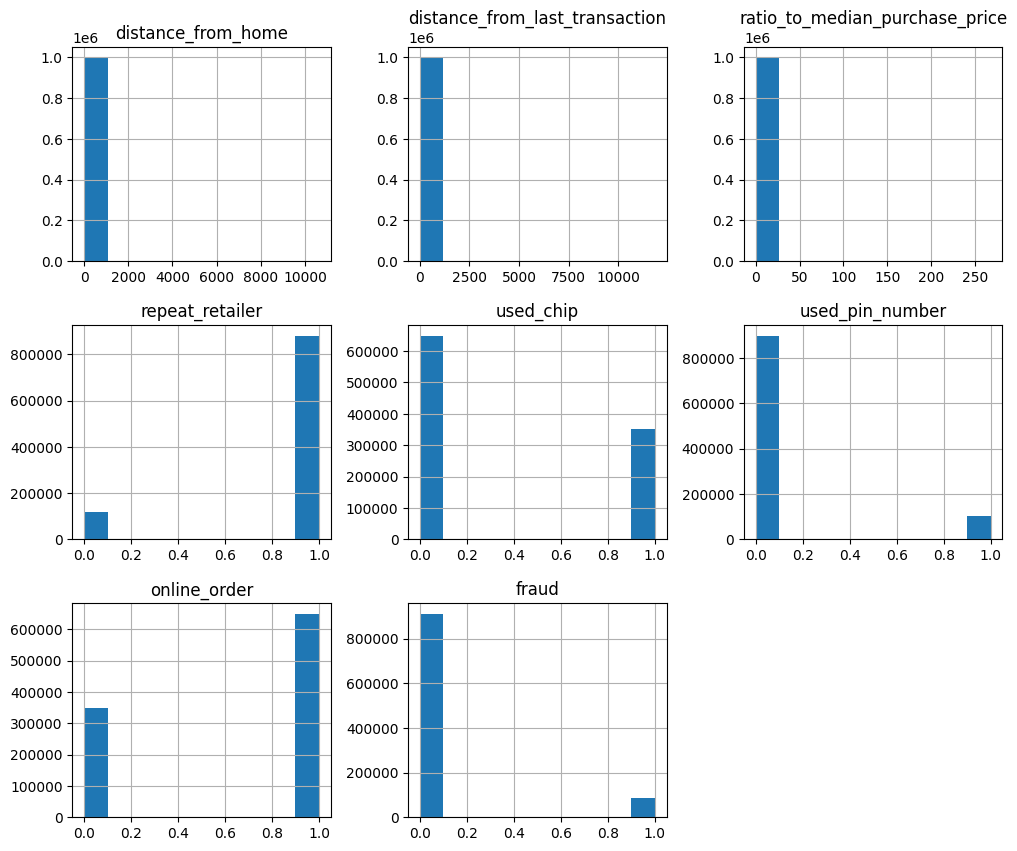

In [42]:
df.hist(figsize=(12, 10))

In [43]:
df.skew(numeric_only=True)

distance_from_home                 20.239733
distance_from_last_transaction    125.921226
ratio_to_median_purchase_price      8.915015
repeat_retailer                    -2.361310
used_chip                           0.627134
used_pin_number                     2.655457
online_order                       -0.631517
fraud                               2.921824
dtype: float64

In [44]:
df.corr(numeric_only=True)['fraud'].sort_values(ascending=False)

fraud                             1.000000
ratio_to_median_purchase_price    0.462305
online_order                      0.191973
distance_from_home                0.187571
distance_from_last_transaction    0.091917
repeat_retailer                  -0.001357
used_chip                        -0.060975
used_pin_number                  -0.100293
Name: fraud, dtype: float64

In [45]:
import numpy as np

np.isinf(df.select_dtypes(include=np.number)).sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [46]:
df['fraud'].unique()

array([0., 1.])

In [47]:
X = df.drop('fraud', axis=1)
y = df['fraud']

In [48]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000000, 7)
y shape: (1000000,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
fraud
0.0    91.25975
1.0     8.74025
Name: proportion, dtype: float64

Test set:
fraud
0.0    91.2595
1.0     8.7405
Name: proportion, dtype: float64


In [51]:
X_train.skew()

distance_from_home                 21.522211
distance_from_last_transaction    139.718000
ratio_to_median_purchase_price      9.374256
repeat_retailer                    -2.359260
used_chip                           0.626474
used_pin_number                     2.653723
online_order                       -0.632183
dtype: float64

array([[<Axes: title={'center': 'distance_from_home'}>,
        <Axes: title={'center': 'distance_from_last_transaction'}>,
        <Axes: title={'center': 'ratio_to_median_purchase_price'}>],
       [<Axes: title={'center': 'repeat_retailer'}>,
        <Axes: title={'center': 'used_chip'}>,
        <Axes: title={'center': 'used_pin_number'}>],
       [<Axes: title={'center': 'online_order'}>, <Axes: >, <Axes: >]],
      dtype=object)

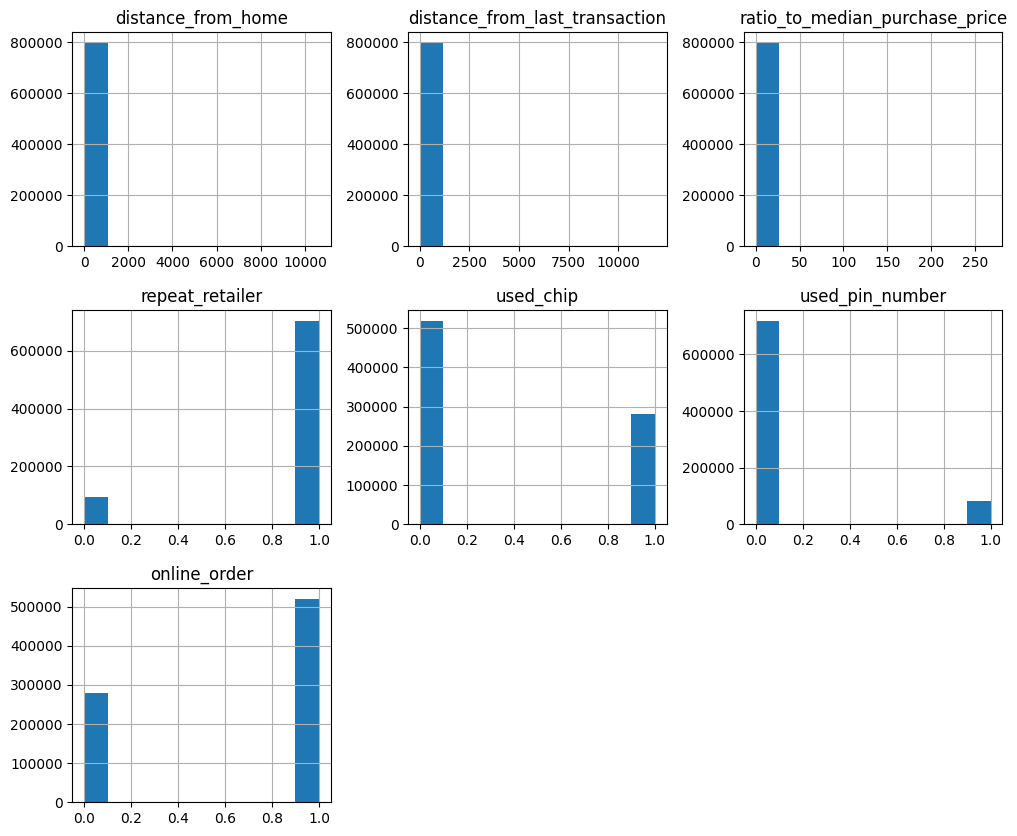

In [52]:
X_train.hist(figsize=(12, 10))

In [53]:
skewed_cols = [
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price'
]

X_train[skewed_cols] = np.log1p(X_train[skewed_cols])
X_test[skewed_cols] = np.log1p(X_test[skewed_cols])

In [54]:
X_train[skewed_cols].skew()

distance_from_home                0.440303
distance_from_last_transaction    1.474990
ratio_to_median_purchase_price    1.208191
dtype: float64

array([[<Axes: title={'center': 'distance_from_home'}>,
        <Axes: title={'center': 'distance_from_last_transaction'}>],
       [<Axes: title={'center': 'ratio_to_median_purchase_price'}>,
        <Axes: >]], dtype=object)

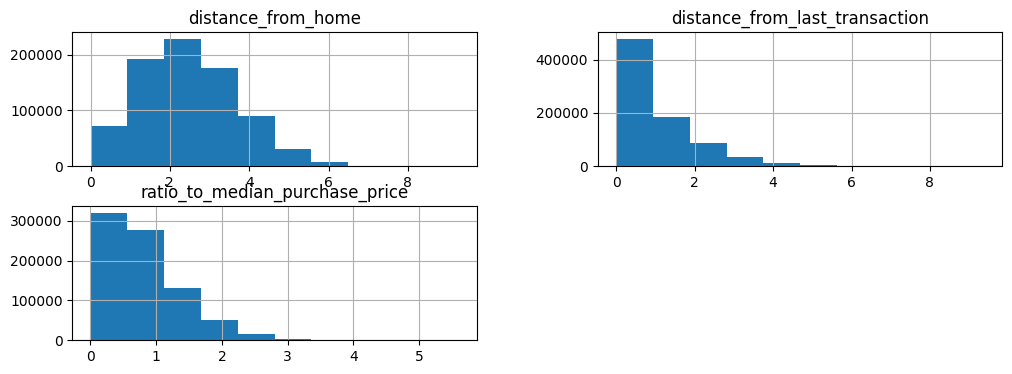

In [55]:
X_train[skewed_cols].hist(figsize=(12, 4))

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [57]:
scaler.fit(X_train[skewed_cols])

,copy,True
,with_mean,True
,with_std,True


In [58]:
X_train[skewed_cols] = scaler.transform(X_train[skewed_cols])
X_test[skewed_cols] = scaler.transform(X_test[skewed_cols])

In [59]:
X_train[skewed_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,800000.0,5.826450e-18,1.000001,-2.068344,-0.753335,-0.079307,0.663595,5.644924
distance_from_last_transaction,800000.0,-1.705303e-18,1.000001,-1.034401,-0.767393,-0.323073,0.477671,8.610549
ratio_to_median_purchase_price,800000.0,5.108802e-17,1.000001,-1.429336,-0.759720,-0.233611,0.529051,8.291581


In [60]:
y_train.value_counts()

fraud
0.0    730078
1.0     69922
Name: count, dtype: int64

In [61]:
y_train.value_counts()[0] / y_train.value_counts()[1]

np.float64(10.441320328365894)

In [62]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (800000, 7)
X_test: (200000, 7)


In [63]:
X_train.columns

Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order'],
      dtype='object')

In [64]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [65]:
X_train.describe().T[['min', 'max']]

,min,max
distance_from_home,-2.068344,5.644924
distance_from_last_transaction,-1.034401,8.610549
ratio_to_median_purchase_price,-1.429336,8.291581
repeat_retailer,0.000000,1.000000
used_chip,0.000000,1.000000
used_pin_number,0.000000,1.000000
online_order,0.000000,1.000000


## Preprocessing Summary

- The dataset contains 1,000,000 transactions and 7 input features.
- No missing or infinite values were found.
- Binary features were already encoded as 0/1.
- Three highly right-skewed numerical features were transformed using log1p().
- The transformed numerical features were standardized using StandardScaler.
- The dataset contains approximately 8.74% fraudulent transactions, indicating class imbalance.
- The training set contains approximately 10.44 legitimate transactions for every fraudulent transaction.
- Class weighting will be considered during model training instead of applying SMOTE initially.
- The test set was kept untouched for unbiased evaluation.

In [67]:
X_train[['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']].value_counts()

repeat_retailer  used_chip  used_pin_number  online_order
1.0              0.0        0.0              1.0             267642
                 1.0        0.0              1.0             144943
                 0.0        0.0              0.0             144069
                 1.0        0.0              0.0              77527
0.0              0.0        0.0              1.0              36063
1.0              0.0        1.0              1.0              30249
0.0              1.0        0.0              1.0              19383
                 0.0        0.0              0.0              19265
1.0              0.0        1.0              0.0              16077
                 1.0        1.0              1.0              15952
0.0              1.0        0.0              0.0              10546
1.0              1.0        1.0              0.0               8659
0.0              0.0        1.0              1.0               4070
                 1.0        1.0              1.0          

In [68]:
np.isinf(X_train).sum().sum(), np.isinf(X_test).sum().sum()

(np.int64(0), np.int64(0))

In [69]:
y_train.value_counts()

fraud
0.0    730078
1.0     69922
Name: count, dtype: int64

In [70]:
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


In [71]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [73]:
print(f"X_train memory: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"X_test memory: {X_test.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

X_train memory: 42.72 MB
X_test memory: 10.68 MB


In [74]:
X_train.to_csv("../dataset/X_train.csv", index=False)
X_test.to_csv("../dataset/X_test.csv", index=False)

y_train.to_csv("../dataset/y_train.csv", index=False)
y_test.to_csv("../dataset/y_test.csv", index=False)

In [75]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800000, 7)
X_test: (200000, 7)
y_train: (800000,)
y_test: (200000,)
